In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from scipy.optimize import fsolve

with sample size- 20 


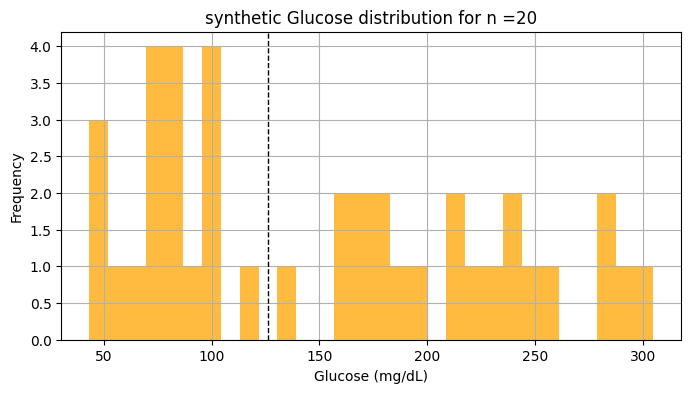

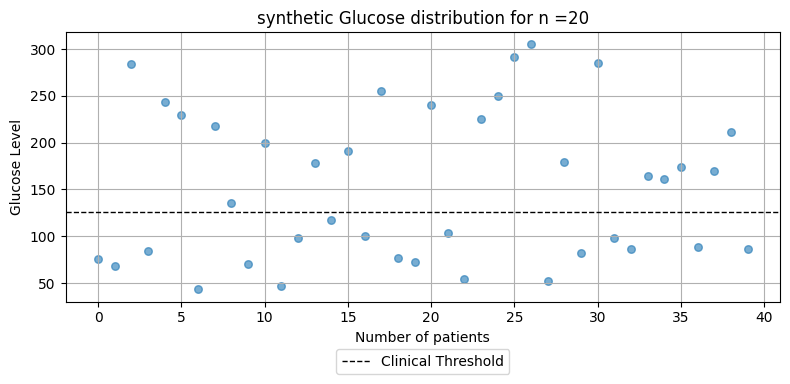

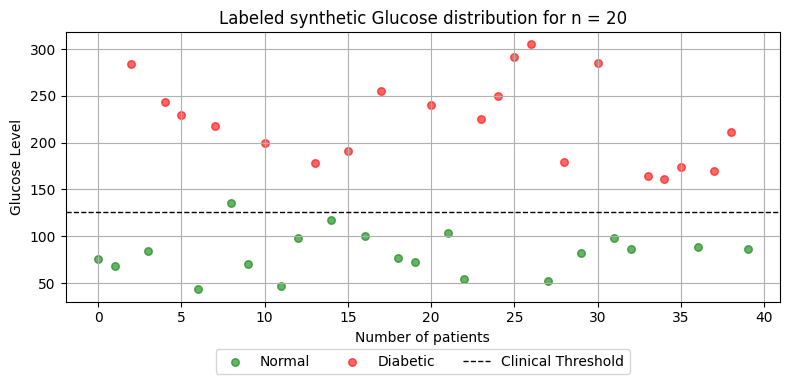

K-means estimated threshold: 152.32 mg/dL


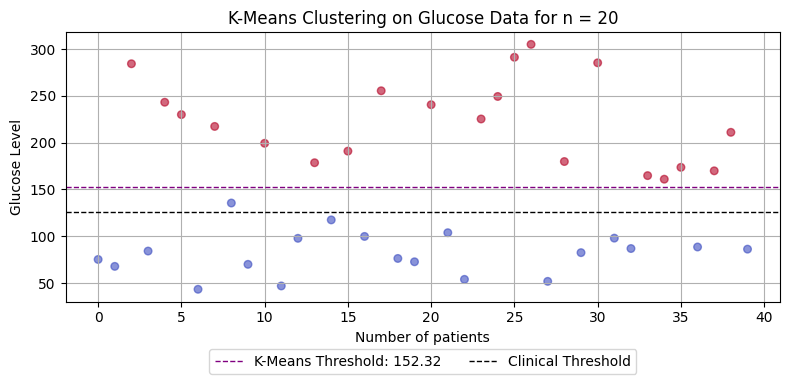

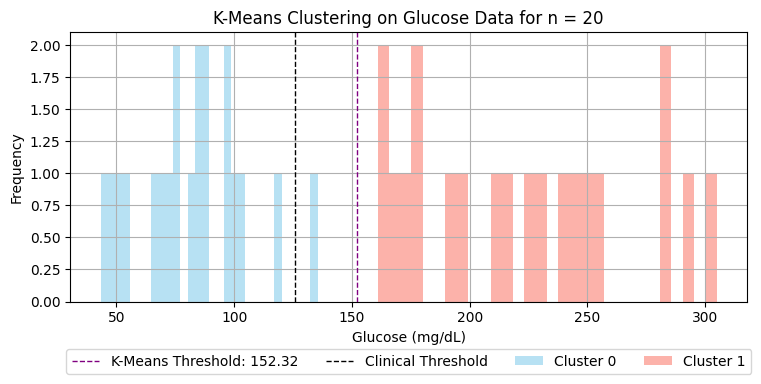

C:\Users\achyu\AppData\Local\Temp\ipykernel_16712\532598633.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


<Figure size 800x400 with 0 Axes>

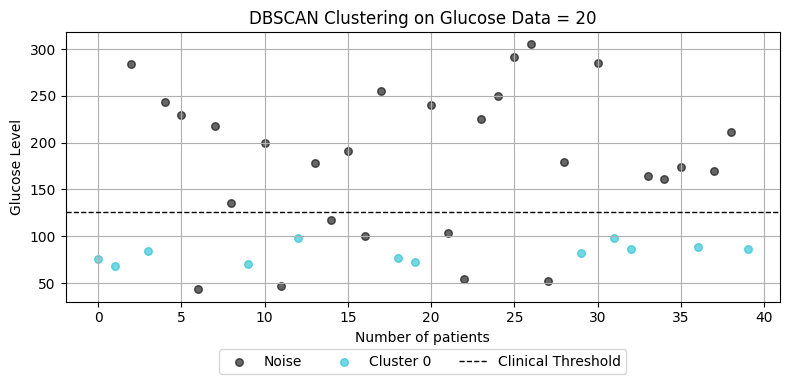

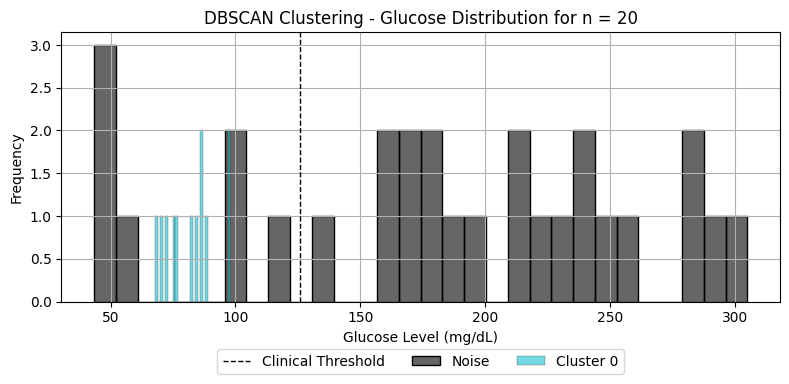

GMM estimated threshold: 121.76 mg/dL


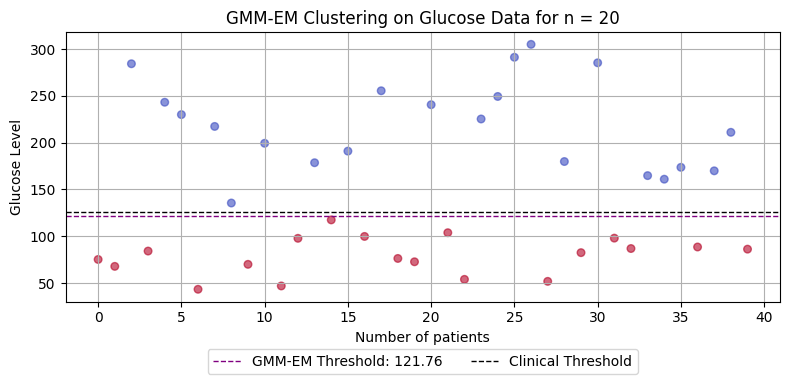

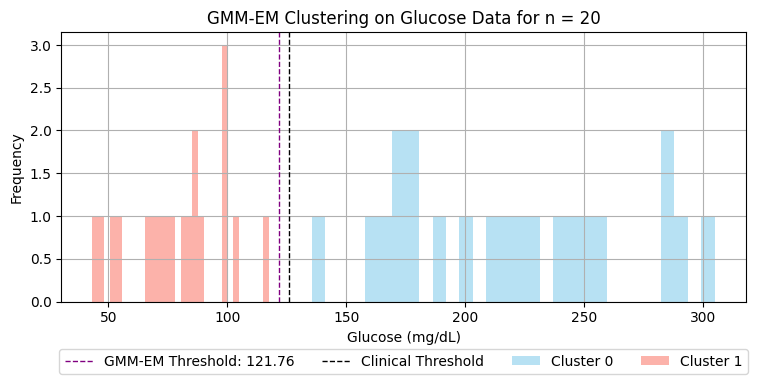

with sample size- 50 


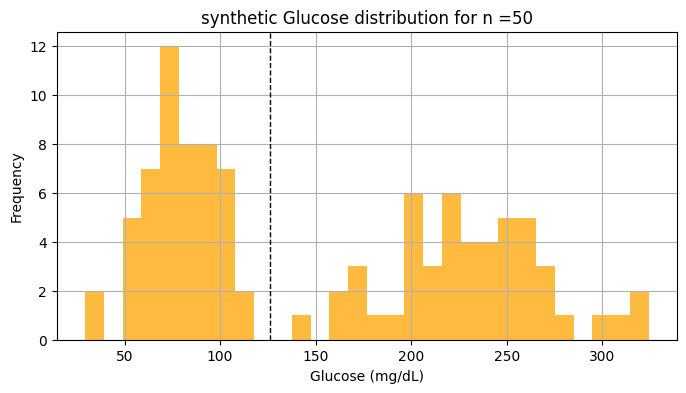

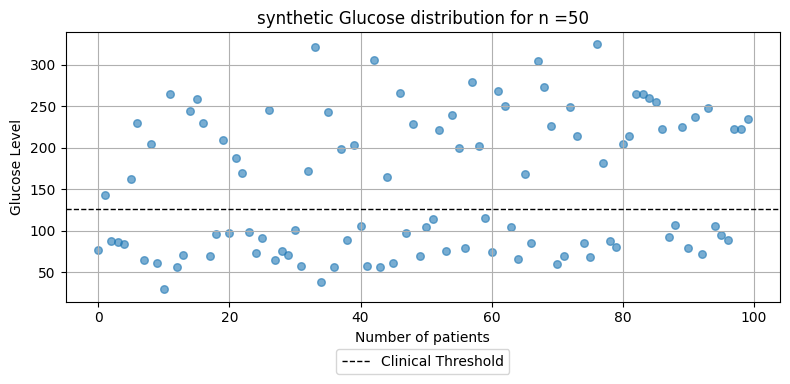

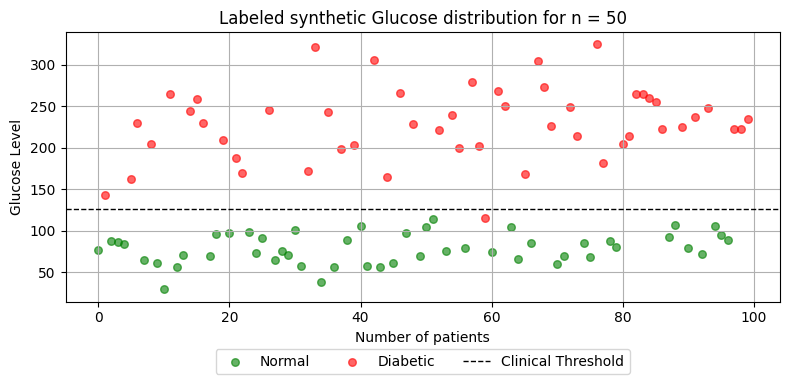

K-means estimated threshold: 156.72 mg/dL


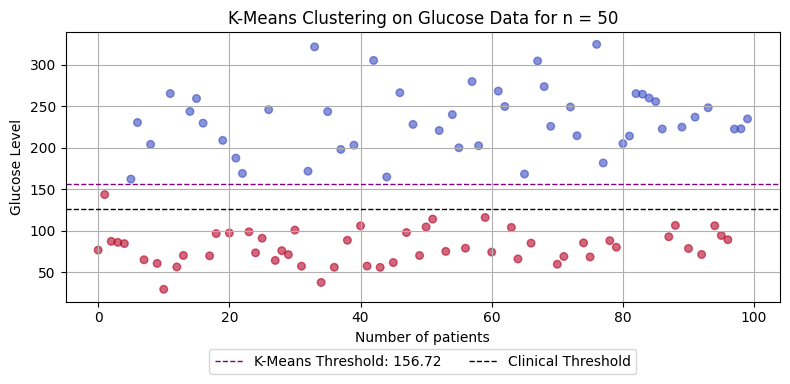

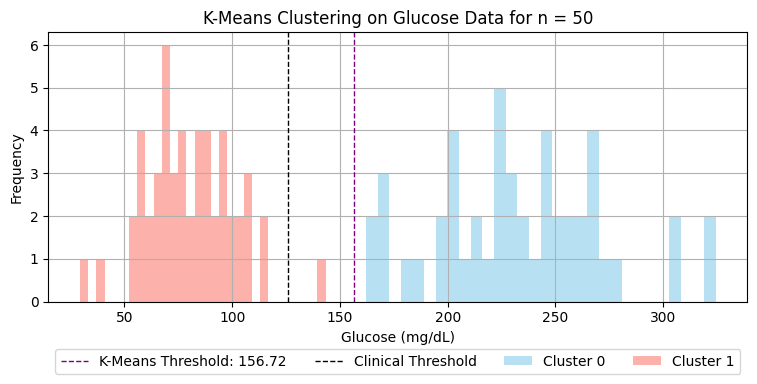

C:\Users\achyu\AppData\Local\Temp\ipykernel_16712\532598633.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


<Figure size 800x400 with 0 Axes>

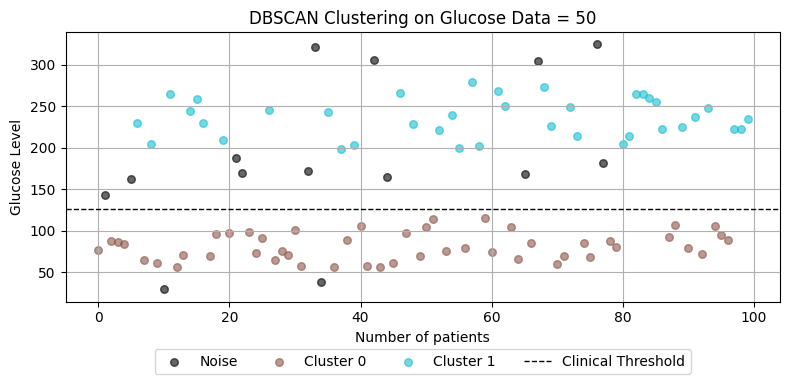

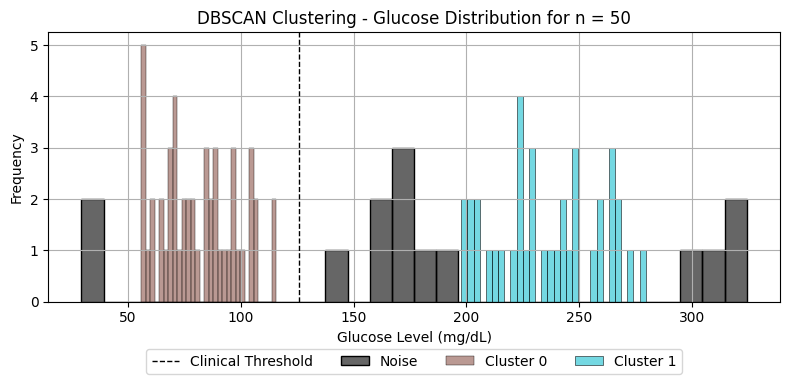

GMM estimated threshold: 130.81 mg/dL


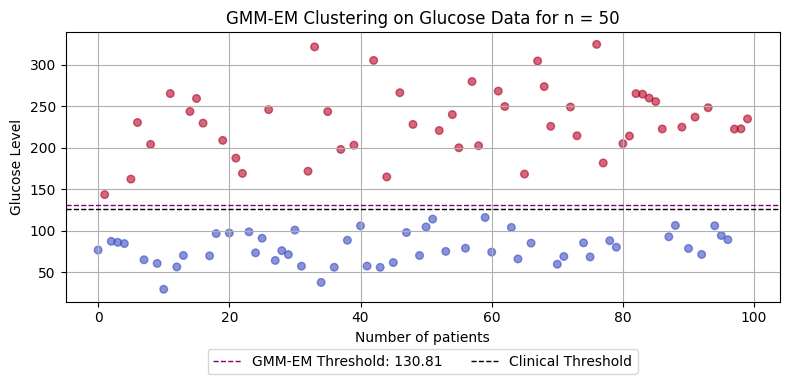

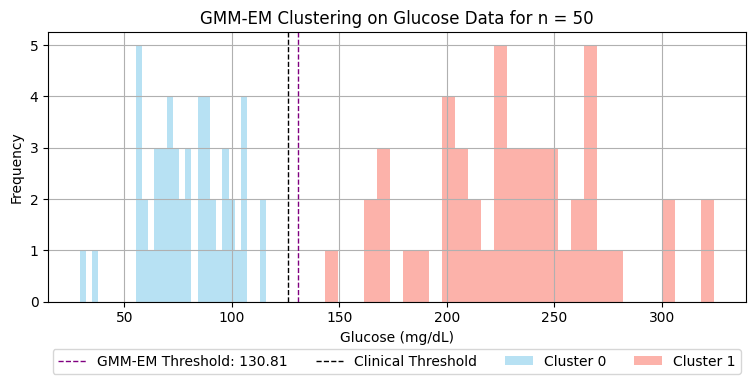

with sample size- 100 


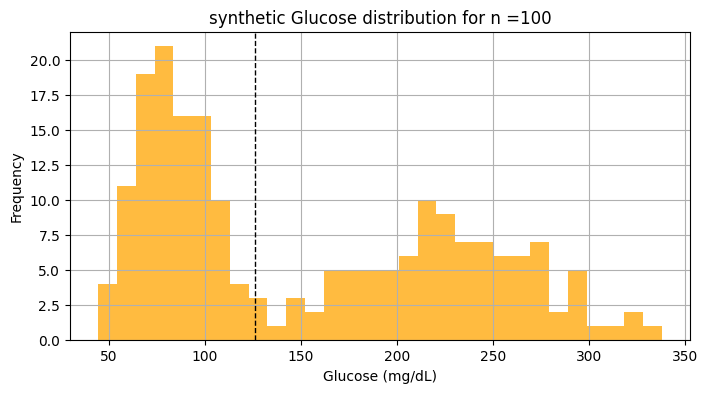

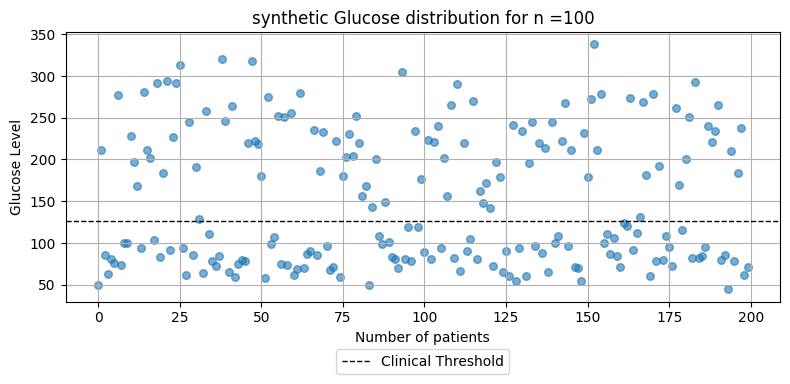

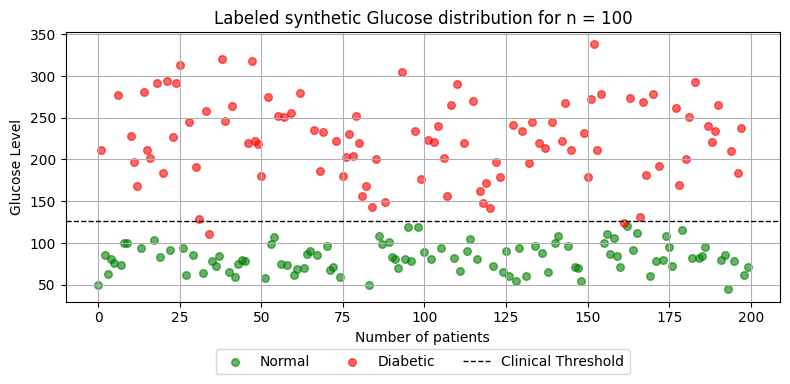

K-means estimated threshold: 160.61 mg/dL


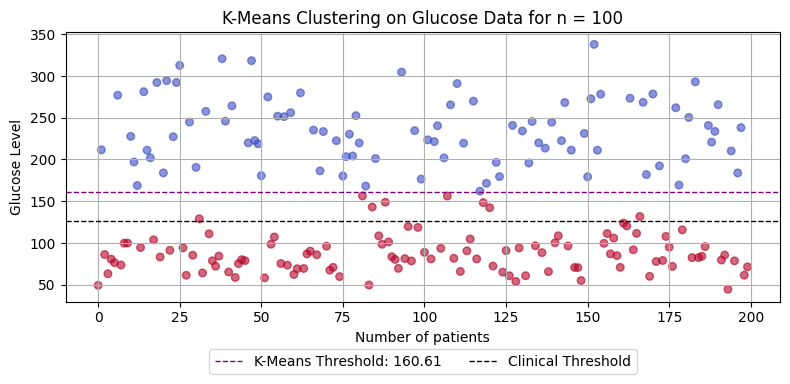

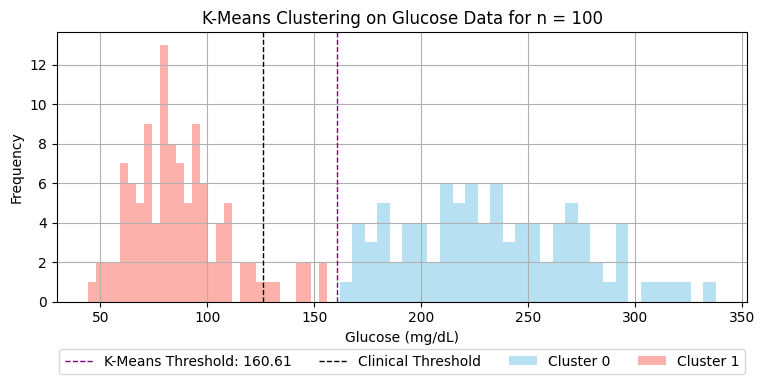

C:\Users\achyu\AppData\Local\Temp\ipykernel_16712\532598633.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


<Figure size 800x400 with 0 Axes>

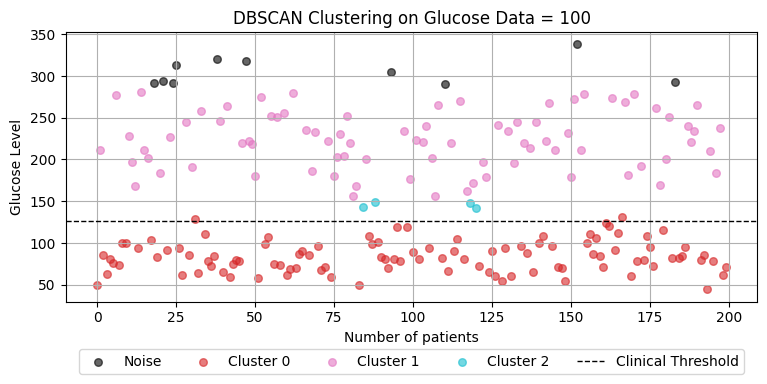

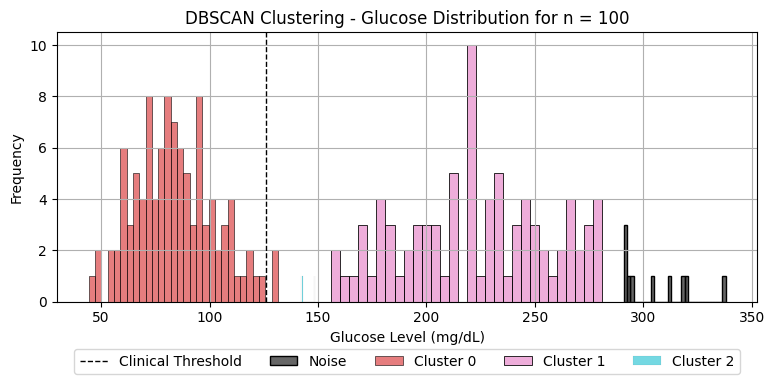

GMM estimated threshold: 126.66 mg/dL


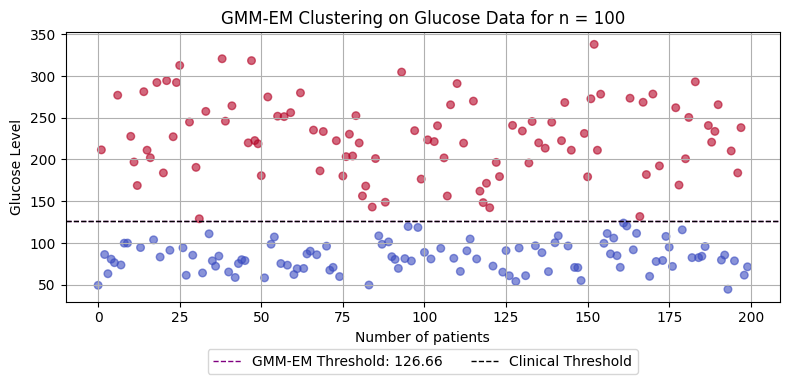

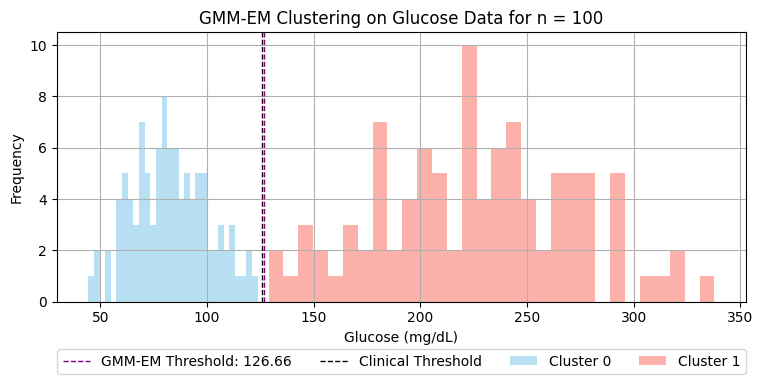

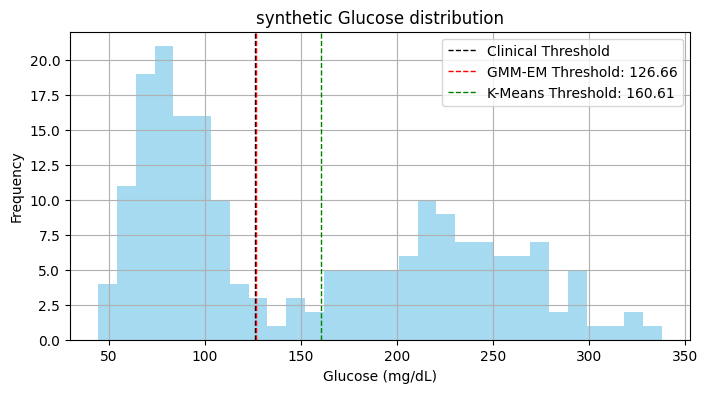

In [42]:
# Function to generate glucose data
def generate_glucose_data(n):
    normal = np.random.normal(loc=80, scale=20, size=n)
    diabetic = np.random.normal(loc=220, scale=50, size=n)
    
    normal_labels = np.zeros(n)
    diabetic_labels = np.ones(n)
    
    X = np.concatenate([normal, diabetic])
    y = np.concatenate([normal_labels, diabetic_labels])
    
    combined = np.column_stack((X, y))
    np.random.shuffle(combined)
    
    X_shuffled = combined[:, 0].reshape(-1, 1)
    y_shuffled = combined[:, 1].astype(int)
    
    return X_shuffled, y_shuffled

np.random.seed(225)    
n = [20, 50, 100]

for i in n:
    print(f"with sample size- {i} ")

    X, y = generate_glucose_data(i)

    # plot 1: original unlabeled distribution of the synthetic glucose data,
    plt.figure(figsize=(8, 4))
    sns.histplot(X.flatten(), bins=30, color="orange", edgecolor=None)
    plt.axvline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.title(f"synthetic Glucose distribution for n ={i}")
    plt.xlabel('Glucose (mg/dL)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


    # Plot 2: Unlabeled scatter plot of the same
    plt.figure(figsize=(8, 4))
    plt.scatter(range(len(X)), X, s=30, alpha=0.6)
    plt.title(f"synthetic Glucose distribution for n ={i}")
    plt.xlabel('Number of patients')
    plt.ylabel('Glucose Level')
    plt.axhline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.grid(True)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.tight_layout()
    plt.show()

    # Plot 3: Labeled scatter plot of the same
    plt.figure(figsize=(8, 4))
    plt.scatter(np.where(y == 0), X[y == 0], label='Normal', c='green', s=30, alpha=0.6)
    plt.scatter(np.where(y == 1), X[y == 1], label='Diabetic', c='red', s=30, alpha=0.6)
    plt.title(f'Labeled synthetic Glucose distribution for n = {i}')
    plt.xlabel('Number of patients')
    plt.ylabel('Glucose Level')
    plt.axhline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    # Standardize the data 
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # K-Means Clustering
    kmeans = KMeans(n_clusters=2, random_state=100)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    centers_scaled = kmeans.cluster_centers_
    centers_original = scaler.inverse_transform(centers_scaled)
    kmeans_threshold = np.mean(centers_original) # Calculate threshold: midpoint between the two cluster centers
    print(f"K-means estimated threshold: {kmeans_threshold:.2f} mg/dL")

    # K-means Plot
    plt.figure(figsize=(8, 4))
    plt.scatter(range(len(X_scaled)), X, c=kmeans_labels, cmap='coolwarm', s=30, alpha=0.6)
    plt.axhline(kmeans_threshold, color='purple', linestyle='--', linewidth=1, label=f'K-Means Threshold: {kmeans_threshold:.2f}')
    plt.axhline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.title(f'K-Means Clustering on Glucose Data for n = {i}')
    plt.xlabel('Number of patients')
    plt.ylabel('Glucose Level')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.histplot(X.flatten()[kmeans_labels == 0], bins=30, color='skyblue', edgecolor=None, alpha=0.6, label='Cluster 0')
    sns.histplot(X.flatten()[kmeans_labels == 1], bins=30, color='salmon', edgecolor=None, alpha=0.6, label='Cluster 1')
    plt.axvline(kmeans_threshold, color='purple', linestyle='--', linewidth=1, label=f'K-Means Threshold: {kmeans_threshold:.2f}')
    plt.axvline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.title(f'K-Means Clustering on Glucose Data for n = {i}')
    plt.xlabel('Glucose (mg/dL)')
    plt.ylabel('Frequency')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # DBSCAN Clustering
    dbscan = DBSCAN(eps=0.12, min_samples=6)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    unique_labels = np.unique(dbscan_labels)
    colors = plt.cm.get_cmap('tab10', len(unique_labels))

    plt.figure(figsize=(8, 4))

    # DBSCAN Plot
    colors_dict = {}
    plt.figure(figsize=(8, 4))
    for idx, label in enumerate(unique_labels):
        mask = dbscan_labels == label
        if label == -1:
            label_name = "Noise"
            color = 'black'
        else:
            label_name = f"Cluster {label}"
            color = colors(idx)
        colors_dict[label] = color
        plt.scatter(np.where(mask)[0], X[mask], s=30, alpha=0.6, label=label_name, c=[color])

    # Calculate cluster-based threshold if possible
    cluster_centers = []
    valid_clusters = [l for l in unique_labels if l != -1]

    if len(valid_clusters) == 2:
        for cluster_id in valid_clusters:
            points_scaled = X_scaled[dbscan_labels == cluster_id]
            center_scaled = points_scaled.mean(axis=0)
            center_original = scaler.inverse_transform([center_scaled])[0]
            cluster_centers.append(center_original)

        cluster_centers = sorted(cluster_centers)
        dbscan_threshold = np.mean(cluster_centers[:2])
    plt.title(f'DBSCAN Clustering on Glucose Data = {i}')
    plt.xlabel('Number of patients')
    plt.ylabel('Glucose Level')
    plt.axhline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Histogram Plot 
    plt.figure(figsize=(8, 4))
    for label in unique_labels:
        mask = dbscan_labels == label
        label_name = "Noise" if label == -1 else f"Cluster {label}"
        color = colors_dict[label]
        sns.histplot(X[mask].flatten(), bins=30, color=color, label=label_name, alpha=0.6)
    plt.axvline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.title(f'DBSCAN Clustering - Glucose Distribution for n = {i}')
    plt.xlabel('Glucose Level (mg/dL)')
    plt.ylabel('Frequency')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    

    # GMM-EM Clustering
    def gaussian_pdf(x, mean, var):
        return norm.pdf(x, loc=mean, scale=np.sqrt(var))

    def run_gmm_em(data, max_iter=100):
        N = len(data)
        data = data.flatten()  # 2D -> 1D
        
        # Initialize parameters
        means = np.random.choice(data, 2)
        var = np.var(data)
        vars_ = [var, var]
        weights = [0.5, 0.5]
        
        for _ in range(max_iter):

            # E-step: compute responsibilities
            r_nk = np.zeros((N, 2))
            for k in range(2):
                r_nk[:, k] = weights[k] * gaussian_pdf(data, means[k], vars_[k])
            r_nk = r_nk / r_nk.sum(axis=1, keepdims=True)  # Normalize responsibilities

            # M-step: update weights, means, variances
            Nk = r_nk.sum(axis=0) #axis=0 : across columns
            means = (r_nk * data[:, np.newaxis]).sum(axis=0) / Nk
            vars_ = ((r_nk * (data[:, np.newaxis] - means) ** 2).sum(axis=0)) / Nk
            weights = Nk / N

        labels = np.argmax(r_nk, axis=1)
        return labels, means, vars_, weights, r_nk

    def find_intersection(mu1, sigma1, w1, mu2, sigma2, w2):
        def equation(x):
            return w1 * norm.pdf(x, mu1, sigma1) - w2 * norm.pdf(x, mu2, sigma2)
        x0 = (mu1 + mu2) / 2
        return fsolve(equation, x0)[0]

    data = X
    gmm_labels, mu, vars_, weights, _ = run_gmm_em(data)

    # Compute threshold (intersection of two Gaussians)
    threshold = find_intersection(mu[0], np.sqrt(vars_[0]), weights[0], mu[1], np.sqrt(vars_[1]), weights[1])
    print(f"GMM estimated threshold: {threshold:.2f} mg/dL")

    # GMM-Em Plot
    plt.figure(figsize=(8, 4))
    plt.scatter(range(len(data)), data, c=gmm_labels, cmap='coolwarm', s=30, alpha=0.6)
    plt.axhline(threshold, color='purple', linestyle='--', linewidth=1, label=f'GMM-EM Threshold: {threshold:.2f}')
    plt.axhline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.title(f'GMM-EM Clustering on Glucose Data for n = {i}')
    plt.xlabel('Number of patients')
    plt.ylabel('Glucose Level')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.histplot(X.flatten()[gmm_labels == 0], bins=30, color='skyblue', edgecolor=None, alpha=0.6, label='Cluster 0')
    sns.histplot(X.flatten()[gmm_labels == 1], bins=30, color='salmon', edgecolor=None, alpha=0.6, label='Cluster 1')
    plt.axvline(threshold, color='purple', linestyle='--', linewidth=1, label=f'GMM-EM Threshold: {threshold:.2f}')
    plt.axvline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
    plt.title(f'GMM-EM Clustering on Glucose Data for n = {i}')
    plt.xlabel('Glucose (mg/dL)')
    plt.ylabel('Frequency')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# conclusion plot for n=100
plt.figure(figsize=(8, 4))
sns.histplot(X.flatten(), bins=30, color="skyblue", edgecolor=None)
plt.axvline(126, color='black', linestyle='--', linewidth=1, label='Clinical Threshold')
plt.axvline(threshold, color='red', linestyle='--', linewidth=1, label=f'GMM-EM Threshold: {threshold:.2f}')
plt.axvline(kmeans_threshold, color='green', linestyle='--', linewidth=1, label=f'K-Means Threshold: {kmeans_threshold:.2f}')
plt.title("synthetic Glucose distribution")
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()